# 評估目標

::: {.callout-tip}

投影片操作：**Alt + 點擊** 可縮放任何圖片/表格（reveal.js zoom）；`O` 鍵總覽、`F` 全螢幕。

:::

**研究提問**：是否存在「機器學習配對 + 深度學習交易」策略，績效優於 SSD/DTW 距離法基準，且年化報酬 $\ge 2\%$？

**資料處理原則**：

- 現役策略清單**動態讀自** `strategies/config.py`——陣容變動時本筆記本自動同步，無需手改白名單
- `result.db` 保留已封存策略的歷史結果，以現役 `db_method` 白名單過濾
- 同一網格鍵若重跑產生多筆，保留最新一筆（防禦性去重）
- 現役但尚無回測數據者（如剛加入的策略）明列為「待回測」
- 所有指標定義與公式見下節「績效指標定義」，與 `strategies/db_utils.py` 實作一致


# 績效指標定義與公式

以下全部指標由 `strategies/db_utils.py::calculate_metrics_from_params()` 計算。
記號：組合每日損益 $\Delta_t$（各配對 `Daily_Delta` 加總）、初始資本 $C_0 = 10{,}000$、
權益 $E_t = C_0 + \sum_{s \le t}\Delta_s$、期末總損益 $\text{PnL} = E_{\text{end}} - C_0$。


## 一、報酬類 {.smaller}

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `Final_Equity` | 期末權益 | $E_{\text{end}} = C_0 + \text{PnL}$ | 回測結束時的組合總值 |
| `Cum_Ret_Raw` | 累積報酬 | $\prod_{m}(1 + r_m) - 1$，$r_m$＝**月末權益**的月報酬 | 全期總報酬（幾何連乘，計複利） |
| `Ann_Ret_Raw` | 年化報酬 | $(1 + \text{Cum\_Ret})^{12/n_{\text{months}}} - 1$ | 幾何年化；**論文主要報酬口徑**、2% 門檻的判準 |

> 月末權益以 `resample("ME").last()` 取得；年化用幾何法（非算術），對複利與時間長度一致。


## 二、風險調整報酬類 {.smaller}

日報酬定義：$r_t = \Delta_t / E_{t-1}$（以前一日真實權益為分母，首日分母補 $C_0$）。

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `Sharpe_Raw` | 夏普比率 | $\sqrt{252}\cdot \dfrac{\overline{r_t}}{\sigma(r_t)}$ | 每單位**總波動**的超額報酬（本口徑 $r_f=0$，未扣無風險利率） |
| `Sortino_Raw` | 索提諾比率 | $\sqrt{252}\cdot \dfrac{\overline{r_t}}{\sigma(r_t^{-})}$，$r_t^{-}$＝負報酬 | 只罰**下行波動**，對稱波動不計入風險 |
| `Calmar_Raw` | 卡瑪比率 | $\dfrac{\text{Ann\_Ret}}{\lvert \text{MDD} \rvert}$ | 每單位**最大回撤**的年化報酬，衡量尾部風險效率 |

> $\sqrt{252}$ 為日頻年化因子（252 交易日）。Sharpe 用全體日報酬標準差；Sortino 只用負日報酬標準差。


## 三、風險類 {.smaller}

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `MDD_Raw` | 最大回撤 | $\min_t \dfrac{E_t - \max_{s\le t} E_s}{\max_{s\le t} E_s}$ | 權益自歷史高點的最大跌幅（負值，越接近 0 越好） |

> 以真實動態權益的滾動最高點計算，非以初始資本為基準。


## 四、交易品質類 {.smaller}

「一筆交易」＝同一配對維持同一持倉方向的一個區段（以 `Position` 變動切段），其損益為該區段 `Daily_Delta` 加總。

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `Win_Rate` | 勝率 | 獲利交易數 / 總交易數 | 正報酬交易的比例 |
| `Profit_Factor` | 獲利因子 | $\dfrac{\text{Gross\_Profit}}{\lvert \text{Gross\_Loss} \rvert}$ | 毛利對毛損之比，$>1$ 才淨賺 |
| `Gross_Profit` / `Gross_Loss` | 毛利 / 毛損 | 獲利交易損益總和 / 虧損交易損益總和 | 拆解損益來源 |
| `Avg_Trade_Days` | 平均持倉天數 | 平倉交易 `Days_Held` 平均 | 週轉速度 |
| `Entries` / `Exits` | 進場 / 正常出場數 | 持倉方向變動計數 | 交易活躍度 |
| `Stop_Losses` / `Forced_Closes` | 停損 / 期末強平數 | 依 `Status` 分類計數 | 風控觸發頻率 |


## 五、資本效率類（文獻口徑）{.smaller}

配對交易為市場中性、資金非全額動用；下列指標區分「承諾資本」與「實際動用資本」。
$\text{max\_pairs} = \text{Top N} \times$ 重疊期數（6）。

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `RCC_Raw` | 承諾資本報酬 | $\text{PnL} / C_0$ | 以固定承諾資本 $C_0$ 計的總報酬 |
| `REC_Raw` | 動用資本報酬 | $\text{PnL} / (n_{\text{traded}} \times C_0/\text{TopN})$ | 以實際交易過的配對資本計 |
| `Avg_Utilization` | 平均資金利用率 | 日均持倉配對數 / max\_pairs | 資金實際動用比例 |
| `Ann_Ret_Employed` | 動用資本年化 | $\text{PnL} / (\text{日均動用資金} \times \text{年數})$ | 只算真正投入資金的年化（GGR fully-invested 口徑） |
| `Excess_Ret_RF` | 無風險超額年化 | 算術年化 $- r_f \times$ 利用率，$r_f=2\%$ | 閒置現金計 $r_f$ 息後的超額 |

> 承諾資本 vs 動用資本的差異反映市場中性策略「帳面報酬率被閒置資金稀釋」的特性——
> `Ann_Ret_Employed` 通常遠高於 `Ann_Ret_Raw`。


# 資料載入與現役陣容


In [1]:
import sqlite3, sys
from pathlib import Path
import pandas as pd
import matplotlib, matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = ["Microsoft JhengHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams.update({"font.size": 14, "figure.dpi": 110})

# 專案根加入 sys.path，動態讀取現役策略清單
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "strategies" / "config.py").exists())
sys.path.insert(0, str(ROOT))
from strategies.config import strategies_raw_all

# 現役 db_method 白名單（排除 formation-only），保留定義順序
ACTIVE = [(s["db_method"], s["trade_method"]) for s in strategies_raw_all if not s.get("formation_only")]
ACTIVE_METHODS = [m for m, _ in ACTIVE]
print(f"現役交易策略 {len(ACTIVE_METHODS)} 個（讀自 strategies/config.py）")

db = ROOT / "results" / "result.db"
raw_df = pd.read_sql("SELECT * FROM strategy_summaries", sqlite3.connect(f"file:{db}?mode=ro", uri=True))
n_archived = (~raw_df["METHOD"].isin(ACTIVE_METHODS)).sum()
df = raw_df[raw_df["METHOD"].isin(ACTIVE_METHODS)].copy()

_grid = ["METHOD", "TOP N", "STOP LOSS %", "MAX SEC %", "ENTRY Z", "DYN Z NUM"]
n0 = len(df); df = df.drop_duplicates(subset=_grid, keep="last").reset_index(drop=True)

have = set(df["METHOD"].unique())
missing = [m for m in ACTIVE_METHODS if m not in have]
print(f"現役網格結果 {len(df)} 筆（去重移除 {n0 - len(df)}）｜排除封存殘留 {n_archived} 筆")
print(f"有數據 {len(have)}/{len(ACTIVE_METHODS)} 策略")
if missing:
    print("待回測（現役但無數據）：")
    for m in missing: print(f"  - {m}")


現役交易策略 15 個（讀自 strategies/config.py）
現役網格結果 225 筆（去重移除 135）｜排除封存殘留 375 筆
有數據 15/15 策略


## 各策略最佳 Sharpe 組合


In [2]:
cols = ["METHOD", "TRADE_METHOD", "TOP N", "STOP LOSS %", "Sharpe_Raw", "Ann_Ret_Raw", "MDD_Raw", "Calmar_Raw", "Win_Rate"]
best_sharpe = (df.loc[df.groupby("METHOD")["Sharpe_Raw"].idxmax(), cols]
                 .sort_values("Sharpe_Raw", ascending=False).reset_index(drop=True))
best_sharpe.style.format({"Sharpe_Raw":"{:.3f}","Ann_Ret_Raw":"{:.2%}","MDD_Raw":"{:.2%}","Calmar_Raw":"{:.2f}","Win_Rate":"{:.1%}"})


,METHOD,TRADE_METHOD,TOP N,STOP LOSS %,Sharpe_Raw,Ann_Ret_Raw,MDD_Raw,Calmar_Raw,Win_Rate
0,DTW (Paper-Fixed),Z-Score,Top 20,15%,0.817,1.80%,-3.12%,0.58,33.6%
1,Agglomerative (Fundamentals-FMP),Z-Score,Top 1,0%,0.356,2.28%,-24.20%,0.09,30.6%
2,Agglomerative (Fundamentals-DRL-THR-FMP),DRL,Top 1,15%,0.326,2.25%,-23.53%,0.10,46.1%
3,SSD (Rolling-DRL-THR),DRL,Top 5,0%,0.309,0.86%,-9.88%,0.09,36.1%
4,Agglomerative (Fundamentals-DRL-THR-yF),DRL,Top 1,15%,0.278,2.28%,-23.92%,0.10,45.0%
5,SSD (Rolling-Distance),Distance,Top 1,0%,0.216,1.69%,-26.59%,0.06,33.6%
6,Agglomerative (Fundamentals-yF),Z-Score,Top 1,0%,0.204,1.56%,-25.65%,0.06,35.9%
7,SSD (Rolling),Z-Score,Top 1,0%,0.203,1.66%,-23.74%,0.07,33.9%
8,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5-Resid),Z-Score,Top 10,0%,0.168,0.48%,-16.78%,0.03,32.6%
9,SSD-DTW-PCA (Paper-Fixed),Z-Score,Top 20,15%,0.144,0.28%,-6.92%,0.04,33.1%


## 各策略最佳年化報酬組合


In [3]:
best_ret = (df.loc[df.groupby("METHOD")["Ann_Ret_Raw"].idxmax(), cols]
              .sort_values("Ann_Ret_Raw", ascending=False).reset_index(drop=True))
best_ret.style.format({"Sharpe_Raw":"{:.3f}","Ann_Ret_Raw":"{:.2%}","MDD_Raw":"{:.2%}","Calmar_Raw":"{:.2f}","Win_Rate":"{:.1%}"})


,METHOD,TRADE_METHOD,TOP N,STOP LOSS %,Sharpe_Raw,Ann_Ret_Raw,MDD_Raw,Calmar_Raw,Win_Rate
0,Agglomerative (Fundamentals-FMP),Z-Score,Top 1,0%,0.356,2.28%,-24.20%,0.09,30.6%
1,Agglomerative (Fundamentals-DRL-THR-yF),DRL,Top 1,15%,0.278,2.28%,-23.92%,0.10,45.0%
2,Agglomerative (Fundamentals-DRL-THR-FMP),DRL,Top 1,15%,0.326,2.25%,-23.53%,0.10,46.1%
3,SSD (Rolling-DRL-THR),DRL,Top 1,5%,0.234,1.97%,-23.74%,0.08,41.0%
4,DTW (Paper-Fixed),Z-Score,Top 20,0%,0.758,1.89%,-3.90%,0.48,34.1%
5,SSD (Rolling-Distance),Distance,Top 1,0%,0.216,1.69%,-26.59%,0.06,33.6%
6,SSD (Rolling),Z-Score,Top 1,0%,0.203,1.66%,-23.74%,0.07,33.9%
7,Agglomerative (Fundamentals-yF),Z-Score,Top 1,0%,0.204,1.56%,-25.65%,0.06,35.9%
8,HDBSCAN (Cluster-SSD-DTW-PCA-PCA5-Resid),Z-Score,Top 1,0%,0.149,0.76%,-21.00%,0.04,30.6%
9,Agglomerative (SEC-PIT-Beta),Z-Score,Top 1,0%,0.105,0.57%,-32.27%,0.02,33.5%


## 最佳 Sharpe 長條圖


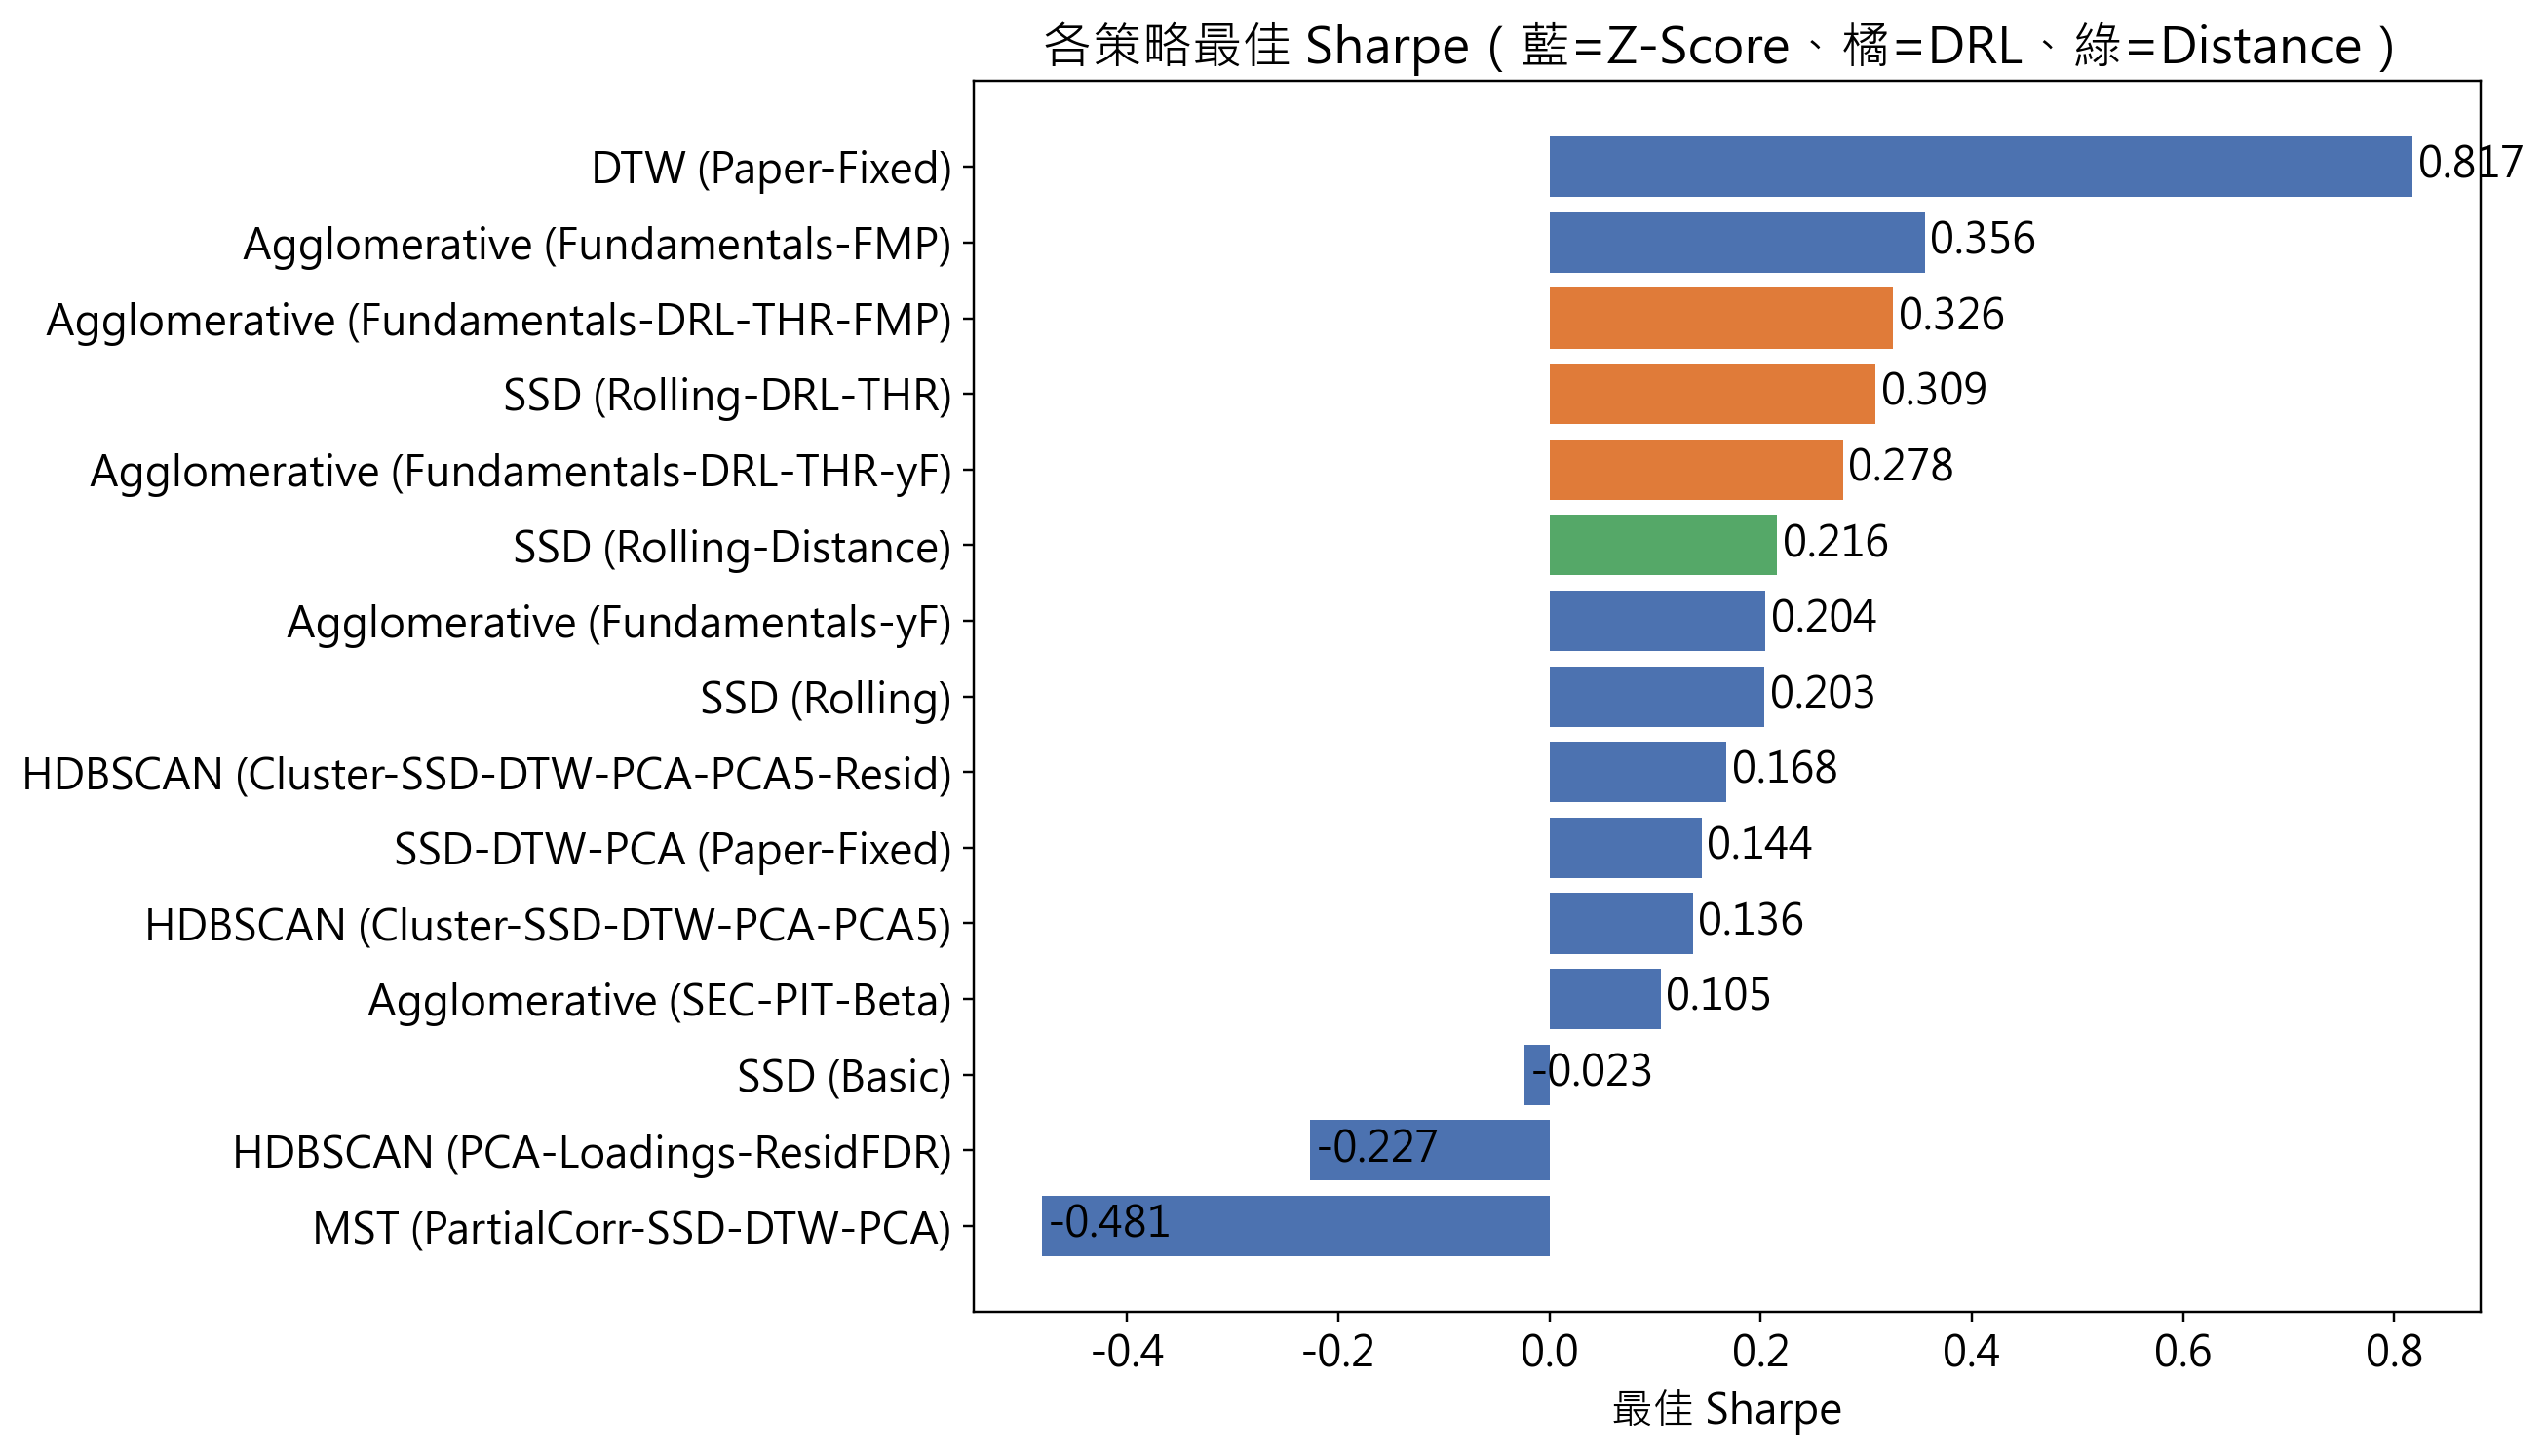

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
d = best_sharpe.sort_values("Sharpe_Raw")
cmap = {"Z-Score":"#4c72b0","DRL":"#e07b39","Distance":"#55a868"}
ax.barh(d["METHOD"], d["Sharpe_Raw"], color=[cmap.get(t,"#888") for t in d["TRADE_METHOD"]])
ax.set_xlabel("最佳 Sharpe"); ax.set_title("各策略最佳 Sharpe（藍=Z-Score、橘=DRL、綠=Distance）")
for i, v in enumerate(d["Sharpe_Raw"]): ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()


## 最佳年化報酬長條圖（2% 門檻線）


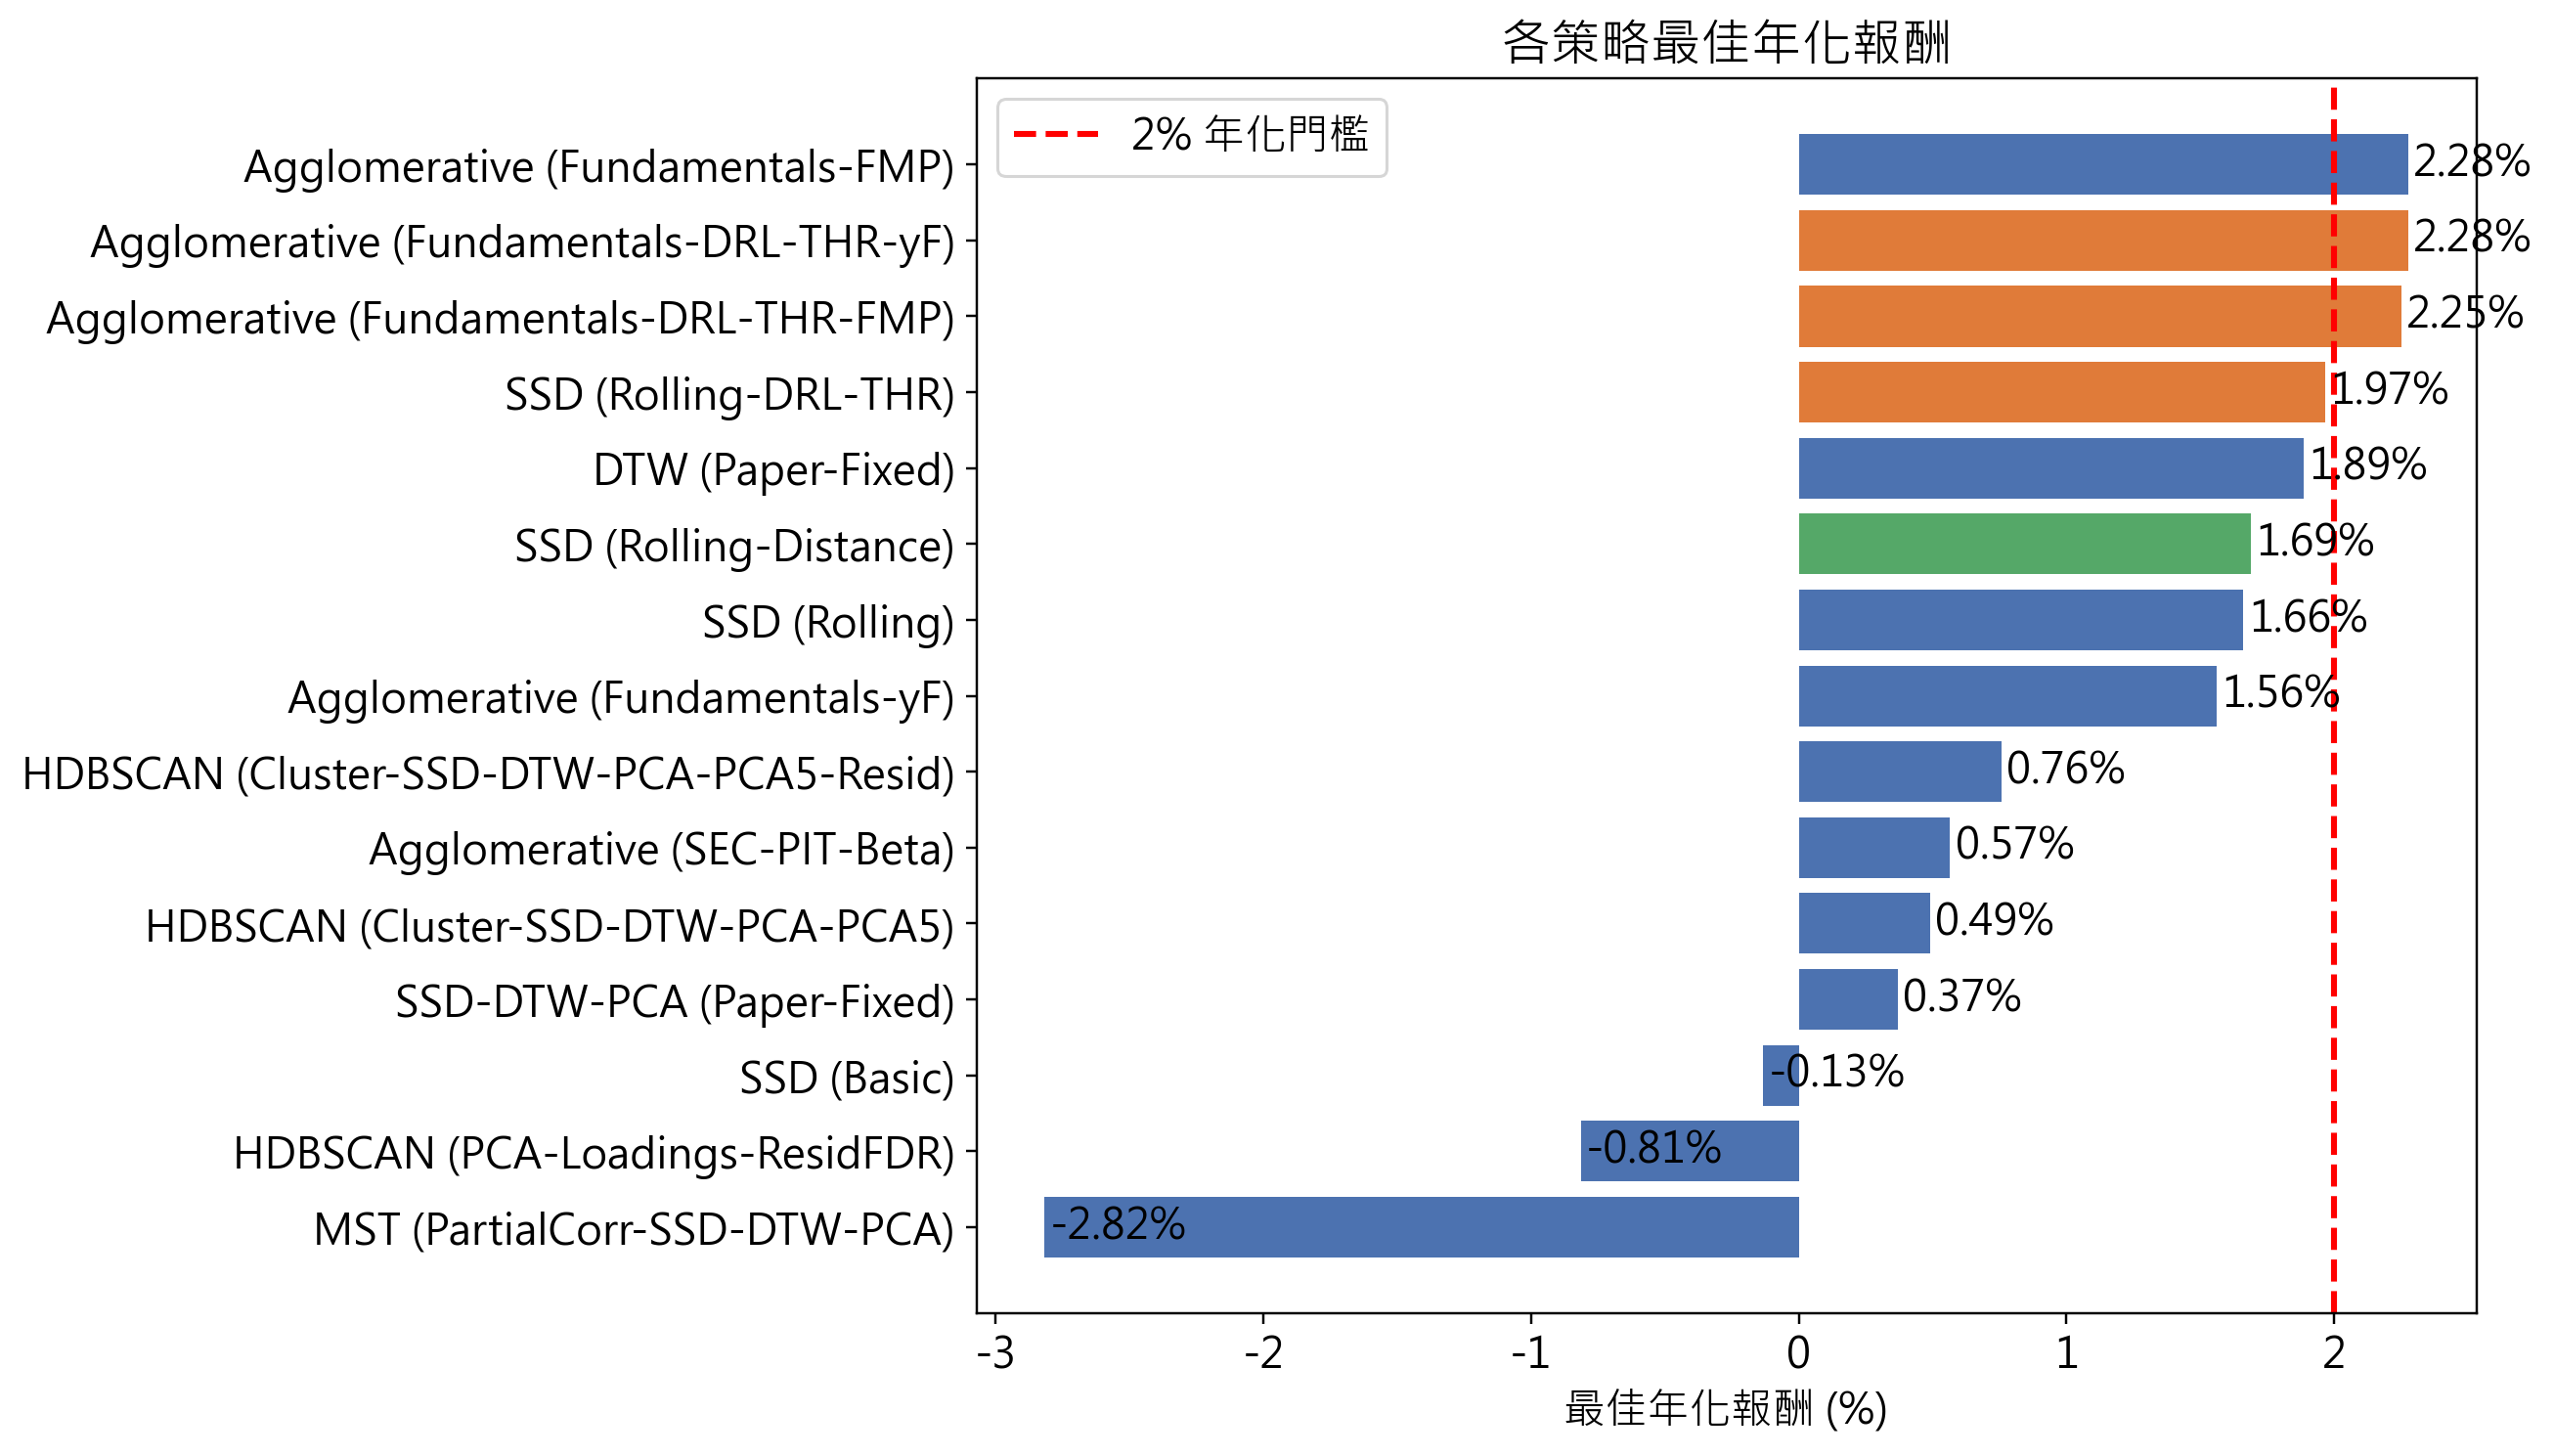

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))
d = best_ret.sort_values("Ann_Ret_Raw")
ax.barh(d["METHOD"], d["Ann_Ret_Raw"]*100, color=[cmap.get(t,"#888") for t in d["TRADE_METHOD"]])
ax.axvline(2.0, color="red", ls="--", lw=2, label="2% 年化門檻")
ax.set_xlabel("最佳年化報酬 (%)"); ax.set_title("各策略最佳年化報酬"); ax.legend()
for i, v in enumerate(d["Ann_Ret_Raw"]*100): ax.text(v + 0.02, i, f"{v:.2f}%", va="center")
plt.tight_layout(); plt.show()


## Sharpe × 年化報酬散佈（全網格）


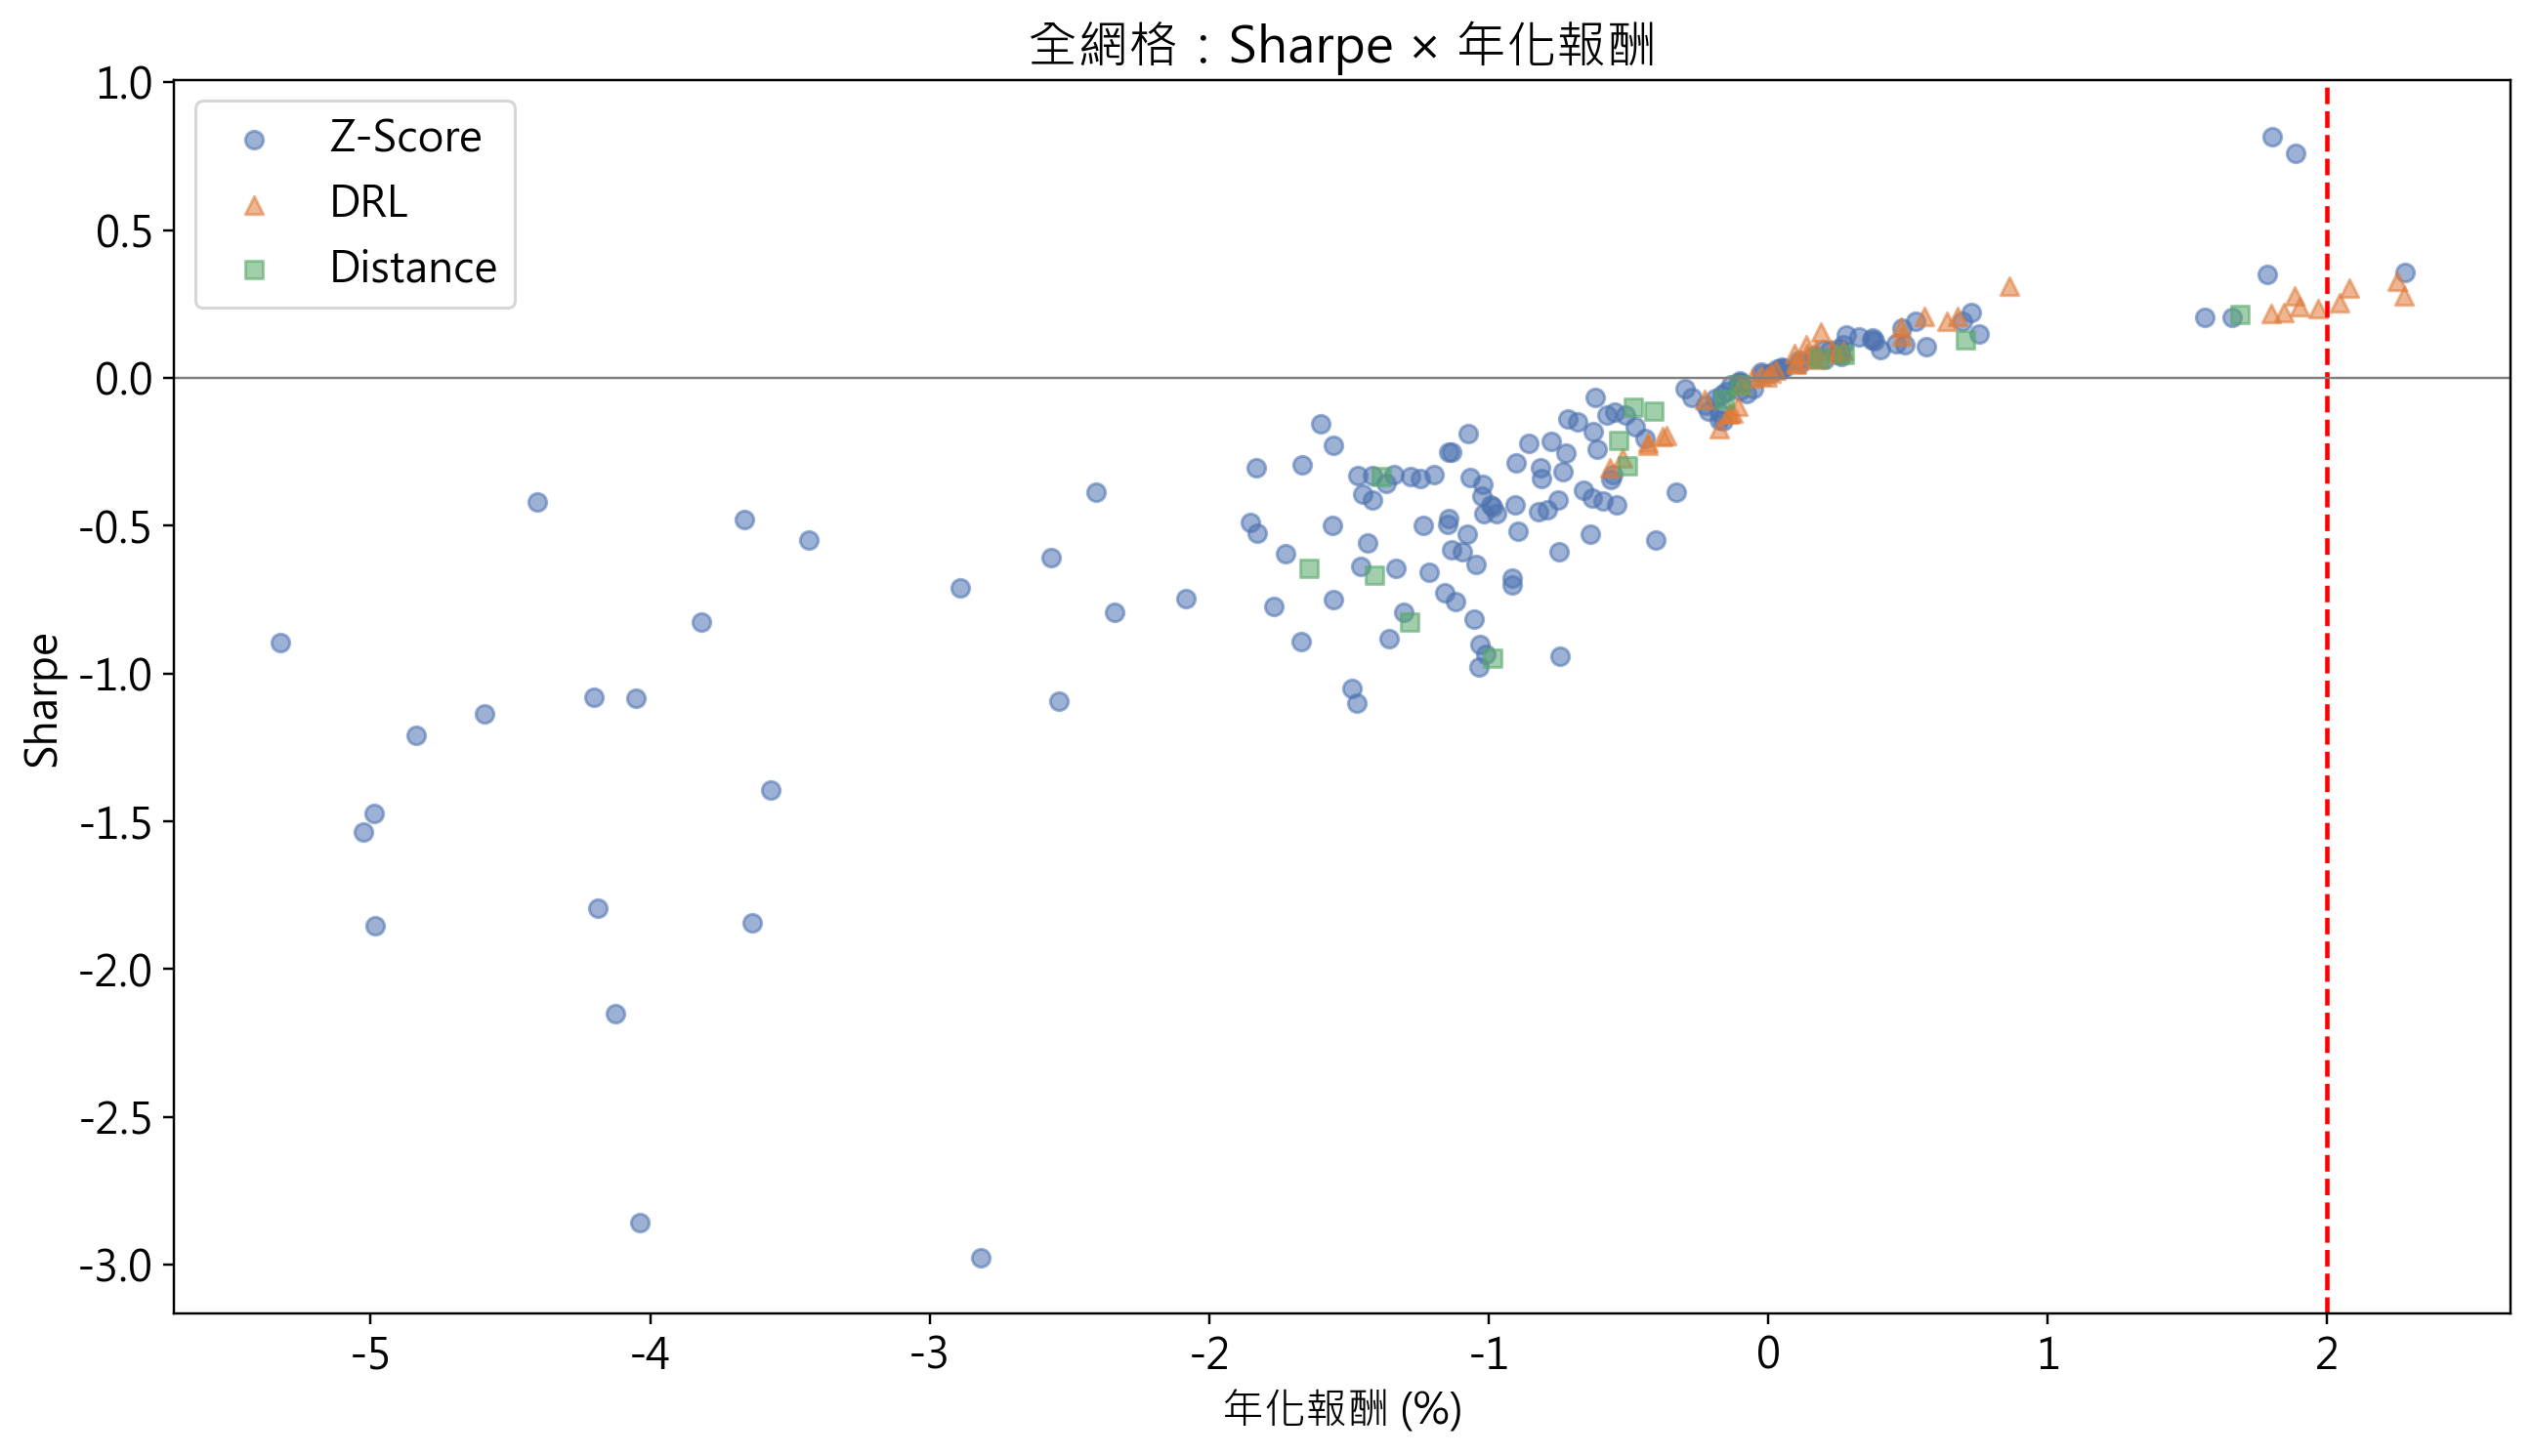

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
for tm, c, mk in [("Z-Score","#4c72b0","o"),("DRL","#e07b39","^"),("Distance","#55a868","s")]:
    sub = df[df["TRADE_METHOD"] == tm]
    if not sub.empty:
        ax.scatter(sub["Ann_Ret_Raw"]*100, sub["Sharpe_Raw"], c=c, marker=mk, alpha=0.55, label=tm)
ax.axvline(2.0, color="red", ls="--", lw=1.5); ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("年化報酬 (%)"); ax.set_ylabel("Sharpe"); ax.set_title("全網格：Sharpe × 年化報酬")
ax.legend(); plt.tight_layout(); plt.show()


## 單變因對照

現役設計了兩組乾淨的單變因消融——形成期配對相同、僅改交易決策邏輯。


In [7]:
def _best(m, col="Sharpe_Raw"):
    s = df[df["METHOD"] == m]
    return (s["Sharpe_Raw"].max(), s["Ann_Ret_Raw"].max()) if not s.empty else (None, None)

# (A) 回歸 vs 距離：SSD Rolling
# (B) Z-Score vs DRL 疊加
pairs = [
    ("回歸 vs 距離", "SSD (Rolling)", "SSD (Rolling-Distance)"),
    ("Z vs DRL：SSD", "SSD (Rolling)", "SSD (Rolling-DRL-THR)"),
    ("Z vs DRL：Agglo(yF)", "Agglomerative (Fundamentals-yF)", "Agglomerative (Fundamentals-DRL-THR-yF)"),
    ("Z vs DRL：Agglo(FMP)", "Agglomerative (Fundamentals-FMP)", "Agglomerative (Fundamentals-DRL-THR-FMP)"),
]
rows = []
for label, a, b in pairs:
    sa, ra = _best(a); sb, rb = _best(b)
    if sa is None or sb is None: continue
    rows.append({"對照": label, "基準": a.split("(")[-1].rstrip(")"), "變體": b.split("(")[-1].rstrip(")"),
                 "Sharpe 基準": sa, "Sharpe 變體": sb, "ΔSharpe": sb-sa,
                 "年化 基準": ra, "年化 變體": rb, "Δ年化": rb-ra})
pd.DataFrame(rows).style.format({"Sharpe 基準":"{:.3f}","Sharpe 變體":"{:.3f}","ΔSharpe":"{:+.3f}",
                                 "年化 基準":"{:.2%}","年化 變體":"{:.2%}","Δ年化":"{:+.2%}"})


,對照,基準,變體,Sharpe 基準,Sharpe 變體,ΔSharpe,年化 基準,年化 變體,Δ年化
0,回歸 vs 距離,Rolling,Rolling-Distance,0.203,0.216,+0.012,1.66%,1.69%,+0.03%
1,Z vs DRL：SSD,Rolling,Rolling-DRL-THR,0.203,0.309,+0.105,1.66%,1.97%,+0.31%
2,Z vs DRL：Agglo(yF),Fundamentals-yF,Fundamentals-DRL-THR-yF,0.204,0.278,+0.074,1.56%,2.28%,+0.72%
3,Z vs DRL：Agglo(FMP),Fundamentals-FMP,Fundamentals-DRL-THR-FMP,0.356,0.326,-0.030,2.28%,2.25%,-0.03%


## DRL-THR 訓練變異數：多輪獨立重跑分布

`strategy_summaries` 只存最後一輪；DRL-THR 未固定隨機種子，
下列統計取自 `results/drl_variance_runs.csv`（`run_drl_variance.py` 多輪完整網格重跑），
**這才是 DRL 策略應引用的正式數字（中位數 ± 範圍）**。


In [8]:
cand = [ROOT/"results"/"analysis"/"drl_variance_runs.csv", ROOT/"results"/"drl_variance_runs.csv"]
var_csv = next((x for x in cand if x.exists()), None)
drl_active = [m for m, t in ACTIVE if t == "DRL"]
if var_csv is not None:
    runs = pd.read_csv(var_csv)
    ra = runs[runs["METHOD"].isin(ACTIVE_METHODS)].copy()
    covered = set(ra["METHOD"].unique())
    if not ra.empty:
        per = (ra.groupby(["METHOD","run_id"]).agg(bs=("Sharpe_Raw","max"), br=("Ann_Ret_Raw","max")).reset_index())
        summ = (per.groupby("METHOD").agg(輪數=("run_id","nunique"),
                Sharpe中位=("bs","median"), Sharpe最小=("bs","min"), Sharpe最大=("bs","max"),
                年化中位=("br","median"), 年化最小=("br","min"), 年化最大=("br","max")).reset_index())
        display(summ.style.format({"Sharpe中位":"{:.3f}","Sharpe最小":"{:.3f}","Sharpe最大":"{:.3f}",
                                   "年化中位":"{:.2%}","年化最小":"{:.2%}","年化最大":"{:.2%}"}))
    else:
        print("variance CSV 中無對得上現役命名的 DRL 策略")
    stale = [m for m in drl_active if m not in covered]
    if stale:
        print("下列現役 DRL 策略的變異數分析尚待以新命名重跑 run_drl_variance.py：")
        for m in stale:
            print("  - " + m)
    print("（variance CSV：" + str(var_csv.relative_to(ROOT)) + "）")
else:
    print("尚無 drl_variance_runs.csv")


,METHOD,輪數,Sharpe中位,Sharpe最小,Sharpe最大,年化中位,年化最小,年化最大
0,SSD (Rolling-DRL-THR),5,0.377,0.340,0.425,2.55%,2.44%,2.72%


下列現役 DRL 策略的變異數分析尚待以新命名重跑 run_drl_variance.py：
  - Agglomerative (Fundamentals-DRL-THR-yF)
  - Agglomerative (Fundamentals-DRL-THR-FMP)
（variance CSV：results\analysis\drl_variance_runs.csv）


## 達標檢核（動態產生）


In [9]:
passed = best_ret[best_ret["Ann_Ret_Raw"] >= 0.02].copy()
print("跨過 2% 年化門檻的策略（依年化排序）：")
for _, r in passed.iterrows():
    print(f"  {r['METHOD']:<45s} 年化 {r['Ann_Ret_Raw']:.2%}｜Sharpe {r['Sharpe_Raw']:.3f}｜{r['TRADE_METHOD']}")
ts = best_sharpe.iloc[0]
print(f"\n全組最高 Sharpe：{ts['METHOD']}（{ts['Sharpe_Raw']:.3f}，年化 {ts['Ann_Ret_Raw']:.2%}）")


跨過 2% 年化門檻的策略（依年化排序）：
  Agglomerative (Fundamentals-FMP)              年化 2.28%｜Sharpe 0.356｜Z-Score
  Agglomerative (Fundamentals-DRL-THR-yF)       年化 2.28%｜Sharpe 0.278｜DRL
  Agglomerative (Fundamentals-DRL-THR-FMP)      年化 2.25%｜Sharpe 0.326｜DRL

全組最高 Sharpe：DTW (Paper-Fixed)（0.817，年化 1.80%）


## 解讀注意事項 {.smaller}

- **指標口徑**：Sharpe/Sortino 以 $r_f = 0$ 計（未扣無風險利率）；年化報酬為幾何口徑。
  資本效率類（`Ann_Ret_Employed`、`Excess_Ret_RF`）才計入 $r_f = 2\%$ 與資金利用率，數值與 `Ann_Ret_Raw` 不可混用比較
- **SSD Basic**：2026-07-06 起為 Gatev/Zhu 論文復刻版（全市場、純距離、無統計過濾），此日期前歷史數據為舊版演算法，不可跨版本比較
- **Agglomerative yF vs FMP**：yF 為單一時點快照（有前視偏誤），FMP 為 Point-in-Time 逐點（已修正前視）——比較時須一併考量資料口徑差異
- **DRL-THR 系**：未固定隨機種子，單次數值有重訓波動；絕對數字以 variance CSV 的中位數±範圍為準，跨策略比較以「基準 → 疊加」的相對方向為準
- **待回測策略**：現役但無數據者於上方明列，回測後重新執行本筆記本即自動納入
